# Credit Card Fraud Detection


**Goal:** Build an end-to-end fraud detection workflow for highly imbalanced transaction data.

## 1. Project Problem Statement

Credit card fraud detection is a binary classification and anomaly-detection problem.

Each transaction is represented by numerical features and a target:

- `Class = 0` → legitimate transaction
- `Class = 1` → fraudulent transaction

The central challenge is **class imbalance**: legitimate transactions greatly outnumber fraudulent ones.

## 2. Setup and Imports

The imports below combine the useful components of the starter notebook with the modeling and evaluation workflow from the more complete project notebook.

In [68]:
import os
import gc
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    silhouette_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


## 3. Load the Credit Card Dataset

The original starter notebook previews only the first 1,000 rows. For modeling, we load the complete CSV when available.

The code checks a few common locations so the notebook is easier to run locally or in Kaggle.

In [69]:
candidate_paths = [
    "./creditcard.csv",
    "/kaggle/input/creditcardfraud/creditcard.csv"
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if data_path is None:
    raise FileNotFoundError(
        "creditcard.csv was not found. Place it beside this notebook "
        "or update candidate_paths with your dataset location."
    )

df = pd.read_csv(data_path)

print(f"Dataset path : {data_path}")
print(f"Shape        : {df.shape}")
display(df.head())

Dataset path : ./creditcard.csv
Shape        : (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Dataset Structure and Quality Checks

Before modeling, verify the target column, data types, missing values, duplicates, and basic descriptive statistics.

In [70]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe().T)

Data types:


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



Missing values:


,missing
Time,0
V16,0
Amount,0
V28,0
V27,0
V26,0
V25,0
V24,0
V23,0
V22,0



Duplicate rows: 1081

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 5. Target Distribution — The Core Challenge

Fraud detection is dominated by legitimate transactions. Always inspect the class distribution before choosing metrics or algorithms.

In [71]:
if "Class" not in df.columns:
    raise ValueError("Expected target column 'Class' was not found.")

class_counts = df["Class"].value_counts().sort_index()
fraud_rate = df["Class"].mean() * 100

print("Class counts:")
display(class_counts.rename(index={0: "Legitimate", 1: "Fraud"}).to_frame("count"))

print(f"Fraud rate: {fraud_rate:.5f}%")

Class counts:


,count
Class,
Legitimate,284315
Fraud,492


Fraud rate: 0.17275%


### Why accuracy is not enough

Suppose 99.8% of transactions are legitimate. A model that predicts **every transaction as legitimate** can obtain very high accuracy while detecting **zero fraud**.

For this reason, the project uses:

- **Precision:** Of transactions flagged as fraud, how many were actually fraud?
- **Recall:** Of all fraudulent transactions, how many did we catch?
- **F1:** Balance between precision and recall.
- **ROC-AUC:** Ranking quality across thresholds.
- **PR-AUC / Average Precision:** Particularly informative when the positive class is rare.

## 6. Explore Transaction Amount and Time

`Amount` and `Time` are directly interpretable columns in the common credit-card-fraud dataset. Their distributions can reveal skew, concentration, and differences between legitimate and fraudulent transactions.

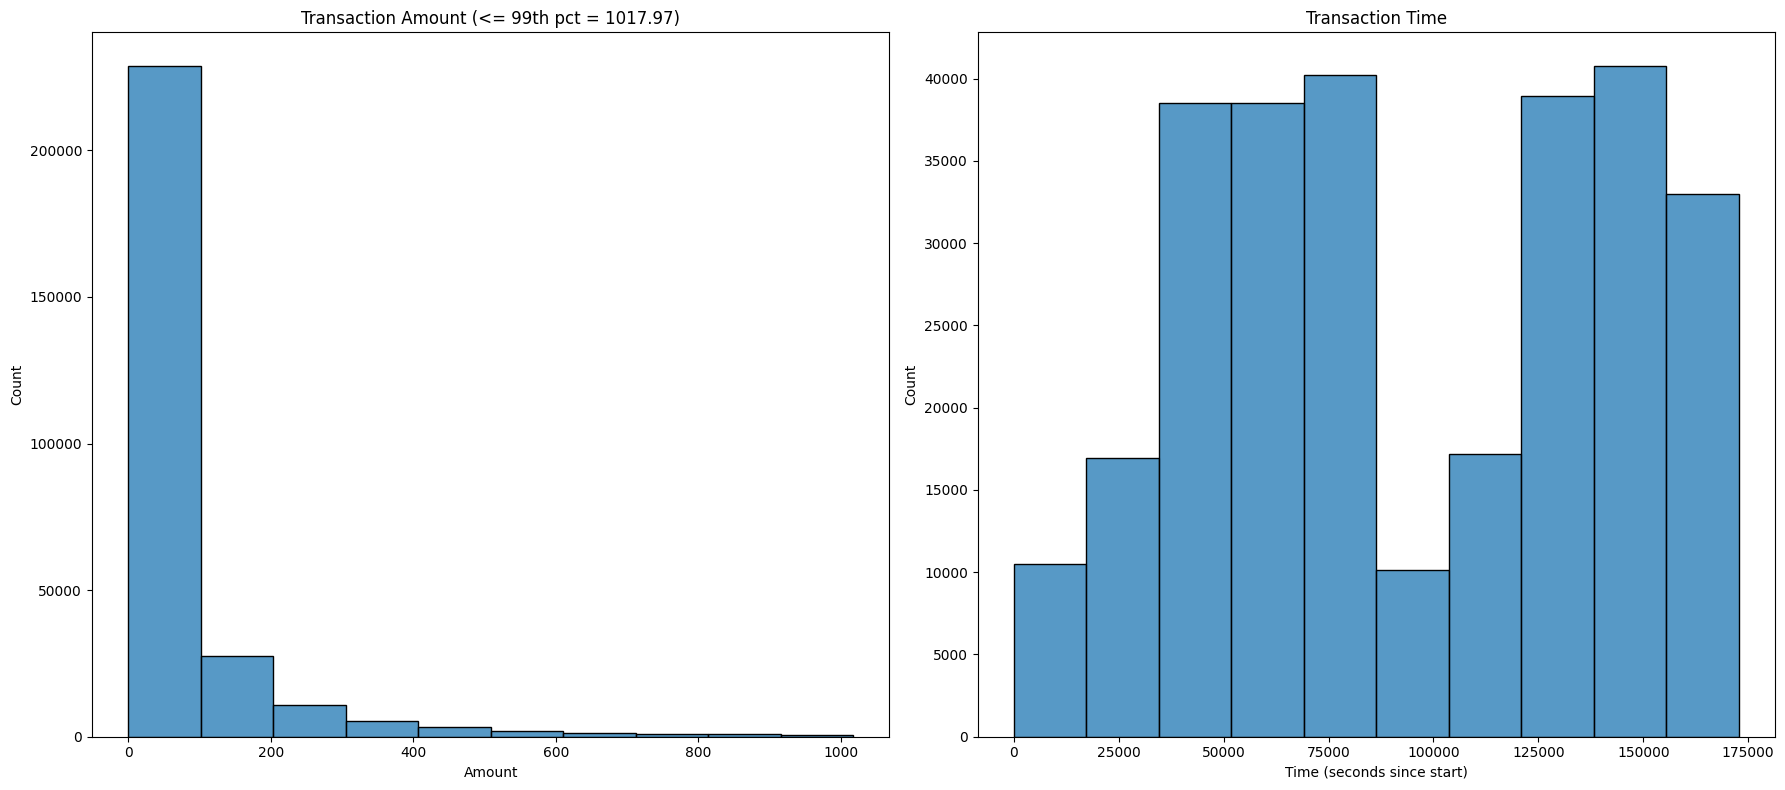

In [72]:
if {"Amount", "Time"}.issubset(df.columns):
    p99 = df["Amount"].quantile(0.99)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    sns.histplot(df.loc[df["Amount"] <= p99, "Amount"], bins=10, ax=axes[0])
    axes[0].set_title(f"Transaction Amount (<= 99th pct = {p99:.2f})")
    axes[0].set_xlabel("Amount")

    sns.histplot(df["Time"], bins=10, ax=axes[1])
    axes[1].set_title("Transaction Time")
    axes[1].set_xlabel("Time (seconds since start)")

    plt.tight_layout()
    plt.show()
else:
    print("Amount and/or Time columns are not available in this dataset.")

## 7. Correlation Analysis

Correlation can provide useful exploratory information, but correlation alone does not determine whether a feature is useful for fraud detection. The target relationship should be treated as exploratory evidence, not as proof of causality.

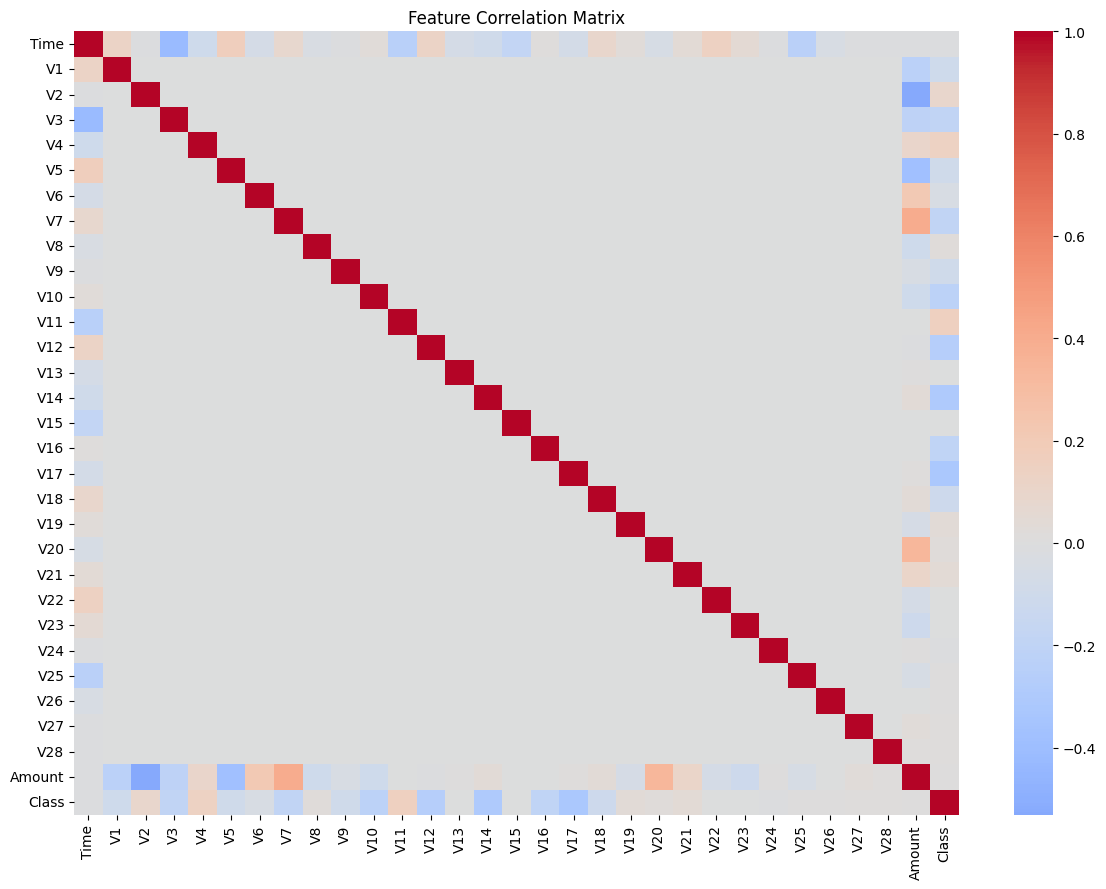

In [73]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Train/Test Split — Stratified and Leakage-Safe

We split before fitting the scaler. Stratification preserves the rare fraud proportion in both partitions.

In [74]:
X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Fraud rate:", y_train.mean())
print("Test :", X_test.shape, "Fraud rate:", y_test.mean())

Train: (227845, 30) Fraud rate: 0.001729245759178389
Test : (56962, 30) Fraud rate: 0.0017204452090867595


## 9. Feature Scaling

`StandardScaler` is fitted **only on the training data** and then applied to the test data. This prevents information from the test set from influencing the learned scaling parameters.

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=X_train.index
).astype("float32")

X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X_test.columns, index=X_test.index
).astype("float32")

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

Scaled train shape: (227845, 30)
Scaled test shape : (56962, 30)


## 10. Smart Stratified Sampling for Heavy Algorithms

Algorithms such as t-SNE, LOF, and some clustering methods can become expensive on hundreds of thousands of rows. We therefore create smaller **stratified** samples for exploratory/unsupervised experiments.

The test set remains untouched for final evaluation.

In [76]:
def fixed_stratified_sample(X_data, y_data, n, random_state=RANDOM_STATE):
    n = min(n, len(X_data))
    sample = X_data.copy()
    sample["_target"] = np.asarray(y_data)

    parts = []
    for label, group in sample.groupby("_target"):
        count = max(1, int(round(n * len(group) / len(sample))))
        parts.append(
            group.sample(
                n=min(count, len(group)),
                random_state=random_state
            )
        )

    result = pd.concat(parts).sample(frac=1, random_state=random_state)
    result = result.iloc[:n]

    y_result = result.pop("_target").astype(int)
    return result, y_result

MAX_VIS = min(10000, len(X_train_scaled))
X_vis, y_vis = fixed_stratified_sample(
    X_train_scaled, y_train, MAX_VIS
)

print("Visualization sample:", X_vis.shape)
print("Fraud rate:", y_vis.mean())

Visualization sample: (10000, 30)
Fraud rate: 0.0017


## 11. PCA — Fast Dimensionality Reduction

PCA creates a lower-dimensional representation that preserves as much variance as possible. It is useful for visualization and for understanding whether the data contains separable structure.

In [77]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2.fit_transform(X_vis)

print("Explained variance ratio:", pca_2.explained_variance_ratio_)
print("Total explained variance:", pca_2.explained_variance_ratio_.sum())

Explained variance ratio: [0.06605037 0.05811772]
Total explained variance: 0.1241681


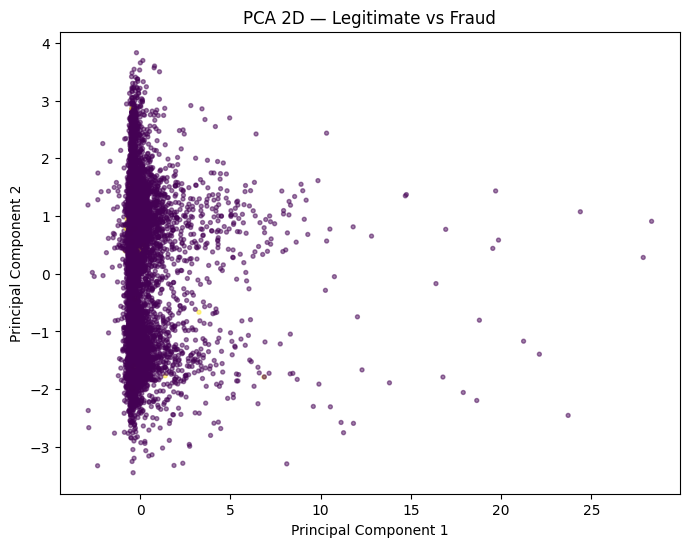

In [78]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=y_vis,
    s=8,
    alpha=0.5
)
plt.title("PCA 2D — Legitimate vs Fraud")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 12. Standard Evaluation Helper

All anomaly models should produce a score where **larger means more suspicious**. This helper evaluates ranking quality with ROC-AUC and PR-AUC.

In [79]:
def evaluate_scores(y_true, anomaly_scores, model_name):
    roc = roc_auc_score(y_true, anomaly_scores)
    pr = average_precision_score(y_true, anomaly_scores)

    print(f"{model_name}")
    print(f"  ROC-AUC: {roc:.4f}")
    print(f"  PR-AUC : {pr:.4f}")

    return {
        "model": model_name,
        "roc_auc": roc,
        "pr_auc": pr
    }

results = []

## 13. K-Means Clustering

K-Means is an unsupervised algorithm that partitions observations into clusters around centroids. It does not know which transactions are fraudulent.

For fraud detection, cluster membership can be explored as a source of anomaly scores, but clusters should not automatically be interpreted as fraud labels.

In [80]:
kmeans = KMeans(
    n_clusters=2,
    n_init=10,
    random_state=RANDOM_STATE
)

kmeans_labels = kmeans.fit_predict(X_vis)
kmeans_distances = kmeans.transform(X_vis).min(axis=1)

print("Cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("Silhouette score:",
      silhouette_score(X_vis, kmeans_labels))

Cluster counts:
0    5462
1    4538
Name: count, dtype: int64
Silhouette score: 0.06616997


### Cluster-to-score mapping

One useful exploratory idea is to see whether a cluster is enriched for fraud. This is **analysis**, not leakage-free prediction: the mapping uses labels and therefore should not be used as a final unsupervised deployment rule without careful validation.

In [81]:
cluster_fraud_rate = pd.DataFrame({
    "cluster": kmeans_labels,
    "fraud": y_vis.to_numpy()
}).groupby("cluster")["fraud"].mean()

display(cluster_fraud_rate.to_frame("fraud_rate"))

cluster_score = np.array([
    cluster_fraud_rate[c] for c in kmeans_labels
])

results.append(
    evaluate_scores(y_vis, cluster_score, "K-Means cluster fraud-rate score")
)

,fraud_rate
cluster,
0,0.001831
1,0.001543


K-Means cluster fraud-rate score
  ROC-AUC: 0.5211
  PR-AUC : 0.0018


## 14. Gaussian Mixture Model

A Gaussian Mixture Model provides soft cluster membership and a density estimate. Transactions with low estimated likelihood can be treated as potentially unusual.

In [82]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="diag",
    random_state=RANDOM_STATE
)

gmm.fit(X_vis)
log_likelihood = gmm.score_samples(X_vis)
gmm_anomaly_score = -log_likelihood

results.append(
    evaluate_scores(y_vis, gmm_anomaly_score, "Gaussian Mixture anomaly score")
)

Gaussian Mixture anomaly score
  ROC-AUC: 0.9641
  PR-AUC : 0.2946


## 15. DBSCAN

DBSCAN groups dense regions and labels sparse observations as noise (`-1`). It can discover irregularly shaped clusters and does not require specifying the number of clusters in advance.

In [83]:
dbscan = DBSCAN(
    eps=2.0,
    min_samples=10,
    n_jobs=-1
)

dbscan_labels = dbscan.fit_predict(X_vis)

noise_rate = np.mean(dbscan_labels == -1)
print("Clusters found:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print(f"Noise rate: {noise_rate:.4%}")

Clusters found: 42
Noise rate: 63.0800%


## 16. Isolation Forest — Main Anomaly Detection

Isolation Forest isolates observations by randomly partitioning the feature space. Rare and unusual observations tend to be isolated in fewer splits.

In [84]:
iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso.fit(X_train_scaled)

iso_score = -iso.score_samples(X_test_scaled)

results.append(
    evaluate_scores(y_test, iso_score, "Isolation Forest")
)

Isolation Forest
  ROC-AUC: 0.9539
  PR-AUC : 0.1717


## 17. Supervised Baseline — Random Forest

Unlike the anomaly detectors above, the supervised model directly uses the fraud labels. We use `class_weight='balanced'` so the rare class receives greater influence during training.

In [85]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_features="sqrt"
)

rf.fit(X_train_scaled, y_train)

rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

rf_roc = roc_auc_score(y_test, rf_proba)
rf_pr = average_precision_score(y_test, rf_proba)

print(f"Random Forest ROC-AUC: {rf_roc:.4f}")
print(f"Random Forest PR-AUC : {rf_pr:.4f}")

Random Forest ROC-AUC: 0.9567
Random Forest PR-AUC : 0.8611


## 18. Precision, Recall and F1 at the Default Threshold

A probability threshold of 0.50 is convenient but is **not automatically optimal for fraud detection**. We inspect it first, then tune the threshold explicitly.

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9998     56864
       Fraud     0.9615    0.7653    0.8523        98

    accuracy                         0.9995     56962
   macro avg     0.9806    0.8826    0.9260     56962
weighted avg     0.9995    0.9995    0.9995     56962



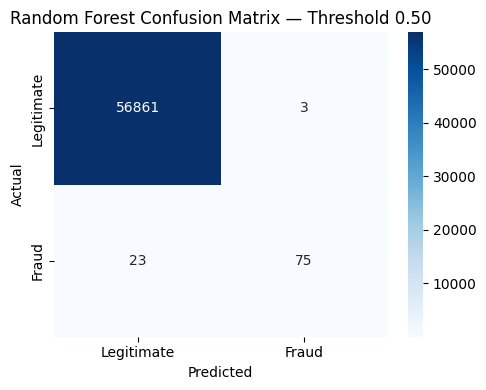

In [86]:
rf_pred_050 = (rf_proba >= 0.50).astype(int)

print(classification_report(
    y_test,
    rf_pred_050,
    target_names=["Legitimate", "Fraud"],
    digits=4
))

cm = confusion_matrix(y_test, rf_pred_050)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.title("Random Forest Confusion Matrix — Threshold 0.50")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 19. Precision–Recall Curve

For rare fraud events, the precision–recall relationship is often more informative than accuracy alone. The curve shows how precision changes as the classifier becomes more or less aggressive about raising fraud alerts.

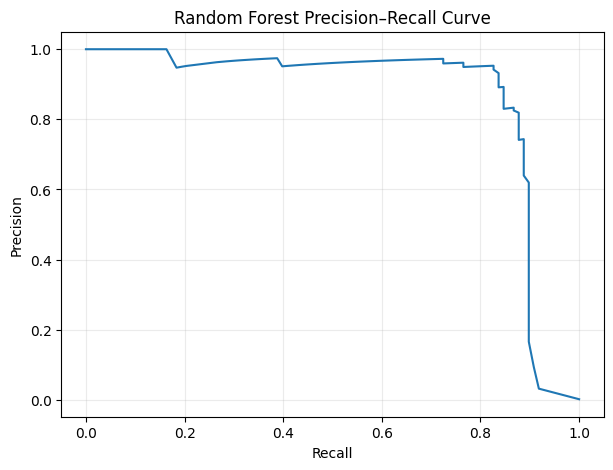

In [87]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision–Recall Curve")
plt.grid(True, alpha=0.25)
plt.show()

## 20 Threshold Tuning

The best threshold depends on the business cost of:

- **False negatives:** fraud that slips through.
- **False positives:** legitimate transactions that are flagged.

Here we select the threshold that maximizes F1 on the test set only as an **illustrative analysis**. For a production system, threshold selection should be performed on a validation set and confirmed on an untouched test set.

In [88]:
threshold_grid = np.linspace(0.01, 0.99, 99)

threshold_rows = []

for threshold in threshold_grid:
    pred = (rf_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_threshold = float(best_row["threshold"])

print("Illustrative best F1 threshold:")
display(best_row.to_frame().T)

Illustrative best F1 threshold:


,threshold,precision,recall,f1
34,0.35,0.952941,0.826531,0.885246


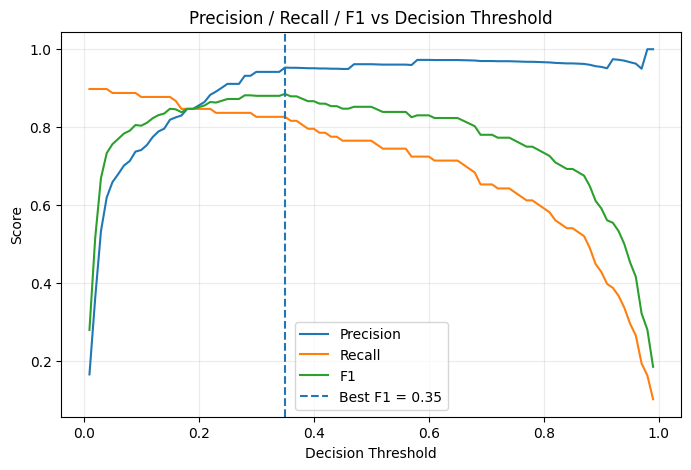

In [89]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Best F1 = {best_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Decision Threshold")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 21. Compare Supervised and Unsupervised Results

The rows below summarize the ranking metrics produced by the different approaches. Remember that they were evaluated under different sampling/training conditions, so this table is best treated as an analytical comparison rather than a perfectly controlled benchmark.

In [90]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    ["pr_auc", "roc_auc"],
    ascending=False
).reset_index(drop=True)

display(comparison)

,model,roc_auc,pr_auc
0,Gaussian Mixture anomaly score,0.964139,0.294601
1,Isolation Forest,0.953929,0.171717
2,K-Means cluster fraud-rate score,0.521053,0.001777


## 22. Supervised Model Summary

In [91]:
supervised_summary = pd.DataFrame([{
    "model": "Random Forest",
    "roc_auc": rf_roc,
    "pr_auc": rf_pr,
    "threshold": best_threshold,
    "precision_at_threshold": best_row["precision"],
    "recall_at_threshold": best_row["recall"],
    "f1_at_threshold": best_row["f1"]
}])

display(supervised_summary)

,model,roc_auc,pr_auc,threshold,precision_at_threshold,recall_at_threshold,f1_at_threshold
0,Random Forest,0.956733,0.861133,0.35,0.952941,0.826531,0.885246


## 23. Feature Importance

Random Forest feature importance can provide a first interpretation of which variables were most useful to the model. Feature importance is not the same as causality.

,importance
V14,0.163248
V4,0.118947
V10,0.116329
V12,0.095941
V17,0.083840
V11,0.067166
V3,0.058029
V16,0.051567
V7,0.028666
V2,0.025397


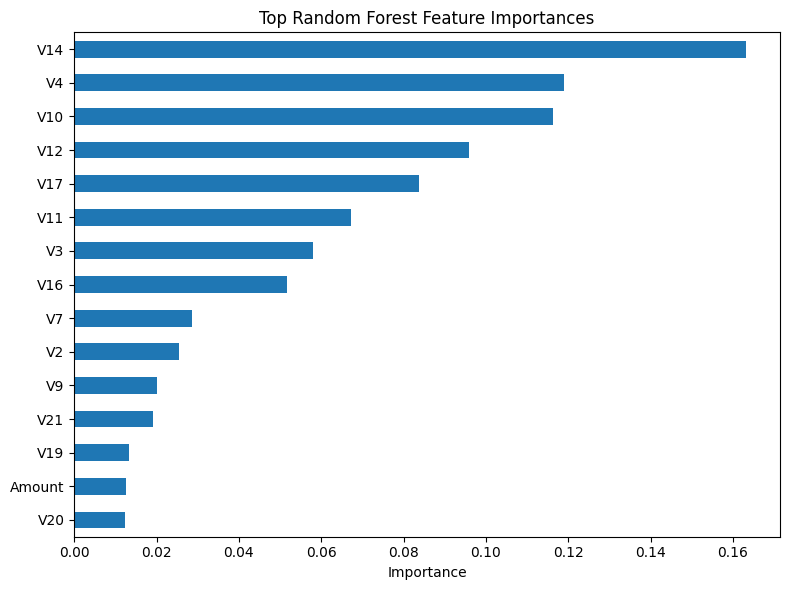

In [92]:
feature_importance = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

display(feature_importance.head(15).to_frame("importance"))

plt.figure(figsize=(8, 6))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()